# Maths Lab E — Linear Algebra for Calibration

This is an **appendix Maths Lab**, not a chapter. Its job is to take the linear
algebra you met as a list of definitions — eigenvectors, Hermitian matrices, the
SVD — and show that **interferometer calibration *is* that linear algebra**, run
on real visibilities. It deepens
[§9 (vectors & linear algebra)](../docs/math-preliminaries.md) and leans on
[§1 (complex numbers & phasors)](../docs/math-preliminaries.md): a gain is a
complex number, calibration is an eigenproblem, and the robust observables of VLBI
fall straight out of the algebra.

Every interferometer measures **corrupted** visibilities. The instrument never
hands you the true sky correlation $V_{ij}^{\text{true}}$; it hands you that
correlation multiplied by an unknown complex **gain** at each antenna:

$$
V_{ij}^{\text{meas}} \;=\; g_i\, g_j^{*}\, V_{ij}^{\text{true}} .
$$

Each $g_i = a_i\,e^{i\phi_i}$ rolls up everything the electronics, cables, and
atmosphere did to antenna $i$'s signal — an amplitude $a_i$ and a phase $\phi_i$.
**Calibration is the act of solving for those gains** so you can divide them back
out. That is the whole game, and underneath it is one matrix equation.

**What you will be able to do by the end:**

- write the measurement equation as a matrix product $V = G\,V_{\text{true}}\,G^{\mathsf H}$
  and see how per-antenna gains corrupt the visibility matrix;
- recover complex gains from an unresolved calibrator by reading the **leading
  eigenvector** of a rank-1 Hermitian matrix (`interferometry.solve_point_source_gains`);
- show *numerically* that **closure phase** is immune to phase errors and
  **closure amplitude** to gain errors — the reason they anchor VLBI;
- diagnose an **ill-conditioned** gain solve with the SVD, and stabilise it by
  truncating the small singular values.

> This Lab runs **fully offline**: only `numpy`, `scipy`, `matplotlib`, and the
> `jansky` helper package. No archives, no network.

## 1. Orientation — calibration as an inverse problem

Why is there a gain at all? Between the sky and the correlator, antenna $i$'s
voltage passes through an amplifier chain, cables of unknown electrical length, a
mixer driven by a local oscillator, and a slab of turbulent atmosphere. Each of
those multiplies the complex voltage by some factor. Bundle them into one complex
number $g_i = a_i e^{i\phi_i}$ and the correlation of antennas $i$ and $j$ — the
visibility — picks up $g_i$ from one arm and $g_j^{*}$ from the other (the
conjugate, because the correlator multiplies $V_i$ by $\overline{V_j}$):

$$
V_{ij}^{\text{meas}} = g_i\,g_j^{*}\,V_{ij}^{\text{true}} .
$$

For an array of $N$ antennas there are $N(N-1)/2$ baselines but only $N$ gains, so
once $N$ is bigger than a handful the problem is **over-determined**: many
measurements, few unknowns. That redundancy is exactly what lets us solve for the
gains from the data themselves — the idea Cornwell & Wilkinson (1981) turned into
**self-calibration**, alternating between "given a sky model, solve the gains" and
"given gains, image the sky" until both settle (see the
[papers timeline](../docs/papers-timeline.md) and Chapter 9).

This Lab strips that loop down to its linear-algebra core. The connection to
[§9](../docs/math-preliminaries.md): a gain solve is an **eigenproblem**, a
robustness proof is an **invariance under diagonal scaling**, and a failure mode
is **ill-conditioning** read off the singular values. Open
`src/jansky/interferometry.py` — the calibration helper is a dozen lines of NumPy
and nothing is hidden.

## Setup

We reuse the course helpers `solve_point_source_gains`, `closure_phase`,
`closure_amplitude`, `simulate_coherent_channels`, and `cross_correlate` from
`jansky.interferometry` unchanged. One seeded generator drives the whole Lab so
the "randomness" is reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from jansky import interferometry
from jansky.interferometry import (
    solve_point_source_gains, closure_phase, closure_amplitude,
    simulate_coherent_channels, cross_correlate,
)
from jansky.plotting import use_jansky_style

use_jansky_style()

# One seeded generator for the whole Lab -> reproducible 'randomness'.
rng = np.random.default_rng(35)

np.set_printoptions(precision=3, suppress=True)
print("Offline Maths Lab ready.")
print("numpy", np.__version__)
print("helpers:", ["solve_point_source_gains", "closure_phase",
                   "closure_amplitude", "simulate_coherent_channels",
                   "cross_correlate"])

Offline Maths Lab ready.
numpy 2.4.6
helpers: ['solve_point_source_gains', 'closure_phase', 'closure_amplitude', 'simulate_coherent_channels', 'cross_correlate']


## 2. The measurement equation as matrices

Collect the per-antenna gains into a **diagonal** matrix
$G = \operatorname{diag}(g_1, \dots, g_N)$, and the true and measured visibilities
into $N \times N$ matrices $V_{\text{true}}$ and $V$. Then the per-baseline rule
$V_{ij} = g_i g_j^{*} V_{ij}^{\text{true}}$ is *exactly* one matrix product:

$$
\boxed{\,V \;=\; G\, V_{\text{true}}\, G^{\mathsf H}\,}
$$

where $G^{\mathsf H}$ is the conjugate transpose (the $g_j^{*}$ on the second arm).
Because $G$ is diagonal, multiplying on the left scales **row** $i$ by $g_i$ and
multiplying on the right by $G^{\mathsf H}$ scales **column** $j$ by $g_j^{*}$ — so
entry $(i,j)$ ends up with $g_i g_j^{*}$, which is the measurement equation. Let us
build a tiny array and watch it happen.

In [2]:
n_ant = 5

# A smooth "true" sky correlation matrix: Hermitian, positive, with structure.
# (Any Hermitian V_true will do for this section; we just need something to corrupt.)
A = rng.standard_normal((n_ant, n_ant)) + 1j * rng.standard_normal((n_ant, n_ant))
V_true = A @ A.conj().T          # Hermitian positive semi-definite by construction
V_true /= np.abs(V_true).max()   # tidy scale

# Per-antenna complex gains: amplitudes near 1, random phases.
amp = rng.uniform(0.7, 1.4, size=n_ant)
phase = rng.uniform(-np.pi, np.pi, size=n_ant)
g = amp * np.exp(1j * phase)
G = np.diag(g)

# The measurement equation, as one matrix product.
V_meas = G @ V_true @ G.conj().T

# Check it entry-by-entry against the per-baseline rule g_i g_j^* V_ij.
expected = np.outer(g, g.conj()) * V_true
print("max |G V_true G^H  -  (g_i g_j^*) V_true| =",
      np.abs(V_meas - expected).max())
print("V is Hermitian:", np.allclose(V_meas, V_meas.conj().T))

max |G V_true G^H  -  (g_i g_j^*) V_true| = 1.3472894910096233e-16
V is Hermitian: True


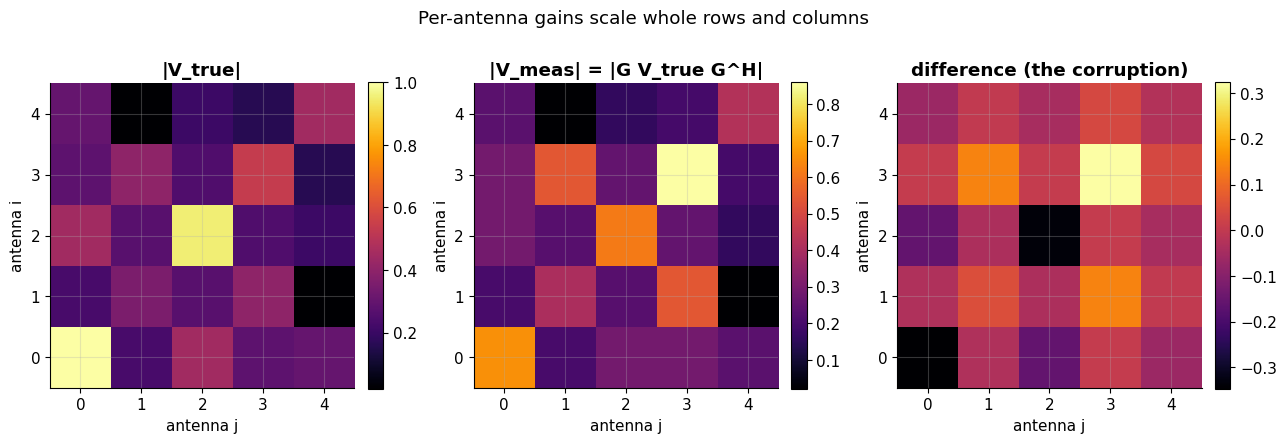

In [3]:
# Visualise what the gains did: amplitude of each visibility, true vs corrupted.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

for ax, M, title in [
    (axes[0], V_true, "|V_true|"),
    (axes[1], V_meas, "|V_meas| = |G V_true G^H|"),
    (axes[2], np.abs(V_meas) - np.abs(V_true), "difference (the corruption)"),
]:
    im = ax.imshow(np.abs(M) if "diff" not in title else M, cmap="inferno")
    ax.set_title(title)
    ax.set_xlabel("antenna j"); ax.set_ylabel("antenna i")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Per-antenna gains scale whole rows and columns", y=1.02)
fig.tight_layout()
plt.show()

Read the middle panel against the left: row $i$ and column $i$ of the
matrix are uniformly brightened or dimmed by antenna $i$'s gain amplitude $a_i$.
That **stripe** structure is the signature of an *antenna-based* error, and it is
the structural fact every calibration algorithm exploits — the corruption has only
$N$ degrees of freedom, not $N^2$.

## 3. Solving for gains on a point source

The cleanest calibrator is an **unresolved point source**: a single dot on the
sky. For a point source the *true* visibility is the same constant on every
baseline (take it to be 1 after normalising), so $V_{ij}^{\text{true}} = 1$ and the
measured matrix is purely the gains:

$$
V_{ij}^{\text{meas}} = g_i\, g_j^{*}
\quad\Longleftrightarrow\quad
V = g\,g^{\mathsf H}.
$$

That is an **outer product** — a rank-1 Hermitian matrix. Its single non-zero
eigenvalue is $\lambda = \lVert g\rVert^2$ and the matching eigenvector is $g$
itself (up to scale). So:

$$
g \;=\; \sqrt{\lambda_{\max}}\;\; \hat{\mathbf v}_{\max},
$$

the leading eigenvector scaled by the square root of the leading eigenvalue.
That is the entire content of `solve_point_source_gains`. There is one
irreducible ambiguity: $g$ and $g\,e^{i\alpha}$ give the *same* $V$ (the phases
$e^{i\alpha}$ and $e^{-i\alpha}$ cancel on every baseline), so the gains are
recoverable only **up to a global phase**. The helper fixes that by rotating so
$g_0$ is real and positive.

In [4]:
# Truth: random complex gains we will try to recover.
g_true = (rng.uniform(0.6, 1.5, size=n_ant)
          * np.exp(1j * rng.uniform(-np.pi, np.pi, size=n_ant)))

# A perfect point-source observation: V = g g^H (no noise yet).
V_point = np.outer(g_true, g_true.conj())
print("rank of V_point =", np.linalg.matrix_rank(V_point, tol=1e-9),
      " (rank-1, as expected)")

# Recover the gains from the leading eigenvector.
g_hat = solve_point_source_gains(V_point)

# Both are only defined up to a GLOBAL phase. Rotate the truth the same way the
# helper rotates its output (make g[0] real positive) so they are comparable.
g_true_ref = g_true * np.exp(-1j * np.angle(g_true[0]))

print("\n  ant |   |g| true   |g| recov  |  phase true  phase recov  (deg)")
for i in range(n_ant):
    print(f"   {i}  |   {abs(g_true_ref[i]):7.3f}   {abs(g_hat[i]):7.3f}  | "
          f"  {np.degrees(np.angle(g_true_ref[i])):8.2f}   "
          f"{np.degrees(np.angle(g_hat[i])):8.2f}")

print("\nmax |g_hat - g_true| (after global-phase alignment) =",
      np.abs(g_hat - g_true_ref).max())

rank of V_point = 1  (rank-1, as expected)

  ant |   |g| true   |g| recov  |  phase true  phase recov  (deg)
   0  |     1.371     1.371  |      -0.00       0.00
   1  |     0.898     0.898  |     -35.12     -35.12
   2  |     1.445     1.445  |      24.45      24.45
   3  |     1.088     1.088  |      97.68      97.68
   4  |     1.323     1.323  |      26.36      26.36

max |g_hat - g_true| (after global-phase alignment) = 2.482534153247273e-16


Exact to machine precision: with noiseless data the eigenvector *is* the
gain. Real life has noise, so let us add some and see how the error behaves — this
is where the over-determination (many baselines, few gains) starts to pay off, the
same averaging-down that **StefCal** and self-cal lean on when they iterate.

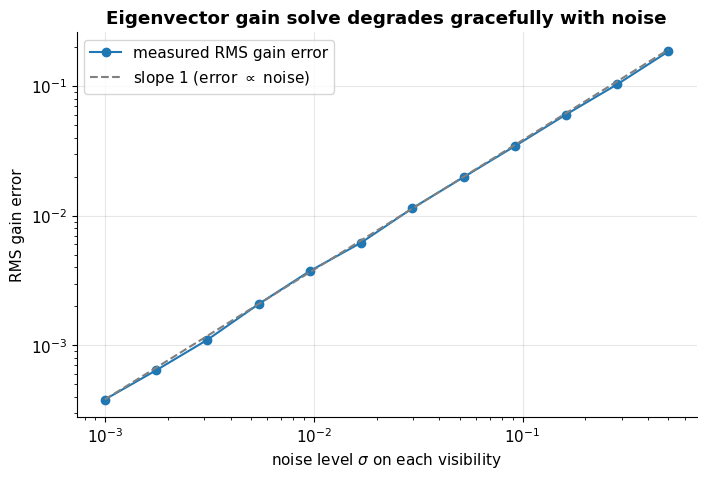

At sigma=0.1, RMS gain error ~ 0.034


In [5]:
def recover_with_noise(g_true, sigma, rng):
    # Corrupt V = g g^H with complex Gaussian noise of std `sigma`, then solve.
    # Noise is added Hermitian-symmetrically so V stays a valid (Hermitian)
    # visibility matrix, exactly as a real correlator would produce.
    n = g_true.size
    V = np.outer(g_true, g_true.conj())
    noise = (rng.standard_normal((n, n)) + 1j * rng.standard_normal((n, n)))
    noise = (noise + noise.conj().T) / 2          # keep it Hermitian
    V_noisy = V + sigma * noise
    g_hat = solve_point_source_gains(V_noisy)
    g_ref = g_true * np.exp(-1j * np.angle(g_true[0]))
    # RMS gain error after global-phase alignment.
    return np.sqrt(np.mean(np.abs(g_hat - g_ref) ** 2))

sigmas = np.geomspace(1e-3, 0.5, 12)
n_trials = 200
errs = []
for s in sigmas:
    trial = [recover_with_noise(g_true, s, rng) for _ in range(n_trials)]
    errs.append(np.mean(trial))
errs = np.array(errs)

fig, ax = plt.subplots()
ax.loglog(sigmas, errs, "o-", label="measured RMS gain error")
# Reference line: error grows linearly with noise level.
ax.loglog(sigmas, errs[0] * sigmas / sigmas[0], "--", color="grey",
          label="slope 1 (error $\\propto$ noise)")
ax.set_xlabel("noise level $\\sigma$ on each visibility")
ax.set_ylabel("RMS gain error")
ax.set_title("Eigenvector gain solve degrades gracefully with noise")
ax.legend()
plt.show()

print(f"At sigma=0.1, RMS gain error ~ {errs[np.argmin(abs(sigmas-0.1))]:.3f}")

The error grows in proportion to the noise — no cliff, no blow-up. The
eigenvector solve effectively **averages over all $N(N-1)/2$ baselines**, so adding
antennas tightens the estimate. This is the kernel of **StefCal** (Salvini &
Wijnholds 2014) and of Cornwell & Wilkinson self-calibration: assume a model
(here, "point source"), solve the gains in closed form, and — when the source is
*not* a point — iterate, re-imaging the sky between gain solves until both
converge.

## 4. Closure quantities are gain-immune

Sometimes you *cannot* calibrate well — the atmosphere over a global VLBI array
scrambles the phases faster than you can track them. The escape hatch is to form
combinations of visibilities in which the antenna gains **cancel algebraically**.
These are the **closure quantities**, and they are pure linear algebra: invariants
of the diagonal scaling $V \mapsto G V G^{\mathsf H}$.

**Closure phase** around a triangle of antennas $(i,j,k)$:

$$
\arg\!\big(V_{ij}\,V_{jk}\,V_{ki}\big).
$$

Substitute $V_{ij} = g_i g_j^{*} V_{ij}^{\text{true}}$ and follow the loop: each
station's phase appears once as $g$ and once as $g^{*}$ around the triangle, so
$\phi_i$ cancels, $\phi_j$ cancels, $\phi_k$ cancels. The closure phase is **free
of all per-antenna phase errors**. Let us confirm it numerically (this mirrors the
EHT demo in Chapter 19).

In [6]:
# Three true baseline visibilities (any complex numbers stand in for a source).
V_ij = rng.standard_normal() + 1j * rng.standard_normal()
V_jk = rng.standard_normal() + 1j * rng.standard_normal()
V_ki = rng.standard_normal() + 1j * rng.standard_normal()

cphase_true = closure_phase(V_ij, V_jk, V_ki)

# Hammer every station with a huge random PHASE error (clock + atmosphere).
phi = rng.uniform(-np.pi, np.pi, size=3)   # per-station phases for i, j, k
def gp(idx): return np.exp(1j * phi[idx])

# Baseline (a,b) picks up g_a * conj(g_b).
V_ij_c = gp(0) * np.conj(gp(1)) * V_ij
V_jk_c = gp(1) * np.conj(gp(2)) * V_jk
V_ki_c = gp(2) * np.conj(gp(0)) * V_ki

cphase_corrupt = closure_phase(V_ij_c, V_jk_c, V_ki_c)

print("per-station phase errors (deg):", np.degrees(phi).round(1))
print("individual visibility phases WRECKED:")
for nm, V0, Vc in [("V_ij", V_ij, V_ij_c), ("V_jk", V_jk, V_jk_c),
                   ("V_ki", V_ki, V_ki_c)]:
    print(f"   arg({nm}): {np.degrees(np.angle(V0)):8.2f}  ->  "
          f"{np.degrees(np.angle(Vc)):8.2f}  deg")
print(f"\nclosure phase: true = {np.degrees(cphase_true):8.3f} deg   "
      f"corrupted = {np.degrees(cphase_corrupt):8.3f} deg")
print(f"difference = {abs(np.degrees(cphase_true - cphase_corrupt)):.2e} deg "
      f"(zero to numerical precision)")

per-station phase errors (deg): [ -67.6   78.4 -133.1]
individual visibility phases WRECKED:
   arg(V_ij):  -145.23  ->     68.76  deg
   arg(V_jk):   -54.33  ->    157.18  deg
   arg(V_ki):  -172.93  ->    121.57  deg

closure phase: true =  -12.484 deg   corrupted =  -12.484 deg
difference = 4.77e-15 deg (zero to numerical precision)


**Closure amplitude** over a quadrangle $(i,j,k,l)$:

$$
\frac{|V_{ij}|\,|V_{kl}|}{|V_{ik}|\,|V_{jl}|}.
$$

Here every station's amplitude $a_i$ shows up once in the numerator and once in the
denominator, so it cancels — the ratio is **free of all per-antenna gain errors**.

In [7]:
# Four true baseline visibilities for the quadrangle.
V_ij2 = rng.standard_normal() + 1j * rng.standard_normal()
V_kl2 = rng.standard_normal() + 1j * rng.standard_normal()
V_ik2 = rng.standard_normal() + 1j * rng.standard_normal()
V_jl2 = rng.standard_normal() + 1j * rng.standard_normal()

camp_true = closure_amplitude(V_ij2, V_kl2, V_ik2, V_jl2)

# Per-station AMPLITUDE errors: each station off by up to a factor ~3.
a = rng.uniform(0.3, 3.0, size=4)   # stations i, j, k, l
# Baseline (p,q) amplitude scales by a_p * a_q.
V_ij2c = a[0] * a[1] * V_ij2
V_kl2c = a[2] * a[3] * V_kl2
V_ik2c = a[0] * a[2] * V_ik2
V_jl2c = a[1] * a[3] * V_jl2

camp_corrupt = closure_amplitude(V_ij2c, V_kl2c, V_ik2c, V_jl2c)

print("per-station gain errors:", a.round(2))
print(f"|V_ij| corrupted from {abs(V_ij2):.3f} to {abs(V_ij2c):.3f} "
      f"(off by x{abs(V_ij2c)/abs(V_ij2):.2f})")
print(f"\nclosure amplitude: true = {camp_true:.5f}   "
      f"corrupted = {camp_corrupt:.5f}")
print(f"difference = {abs(camp_true - camp_corrupt):.2e} "
      f"(zero to numerical precision)")

per-station gain errors: [2.66 2.21 1.17 1.55]
|V_ij| corrupted from 1.884 to 11.104 (off by x5.90)

closure amplitude: true = 7.49465   corrupted = 7.49465
difference = 1.78e-15 (zero to numerical precision)


**This is *why* closure quantities matter.** When calibration is hard or
impossible — sparse global arrays, fast atmospheric phase, no good calibrator — you
throw away the corrupted individual visibilities and keep the closure phases and
amplitudes, because they carry *real information about the source* that no
per-antenna error can touch. They are what let the Event Horizon Telescope image
M87\* from a handful of stations (Chapter 19).

## 5. SVD & ill-conditioning

The point-source solve worked because $V = g g^{\mathsf H}$ has *one* dominant
eigenvalue cleanly separated from zero. When that separation shrinks — low SNR, or
an array geometry where the gains are nearly degenerate — the problem becomes
**ill-conditioned**: the answer reacts violently to tiny changes in the data.

The diagnostic is the **singular value decomposition** $M = U\,\Sigma\,V^{\mathsf H}$.
The singular values $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$ on the diagonal of
$\Sigma$ measure how much "stretch" the matrix applies along each direction. The
**condition number** $\kappa = \sigma_{\max}/\sigma_{\min}$ tells you how much
relative error gets amplified: if $\sigma_{\min}$ is nearly zero, $\kappa$ is huge
and the inverse is numerically worthless.

Take a gain-solve cast as a small linear system $M\,x = b$. We make $M$ slide from
well-conditioned toward near-degenerate and watch the SVD light up.

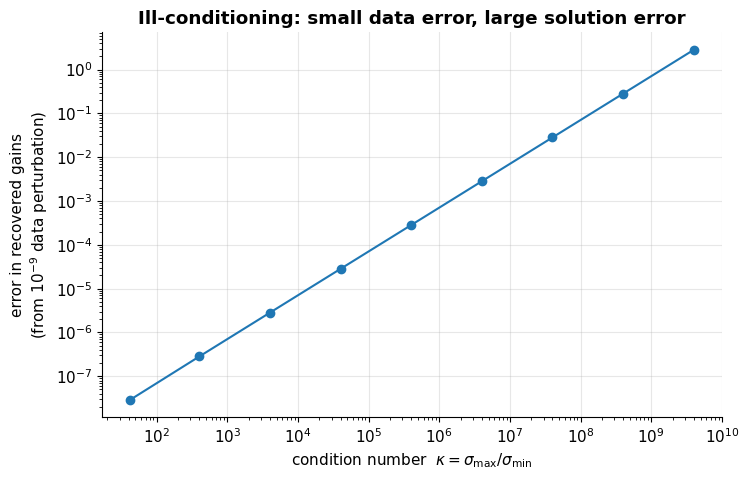

epsilon = 1e-01   condition number = 4.208e+01
epsilon = 1e-02   condition number = 4.020e+02
epsilon = 1e-03   condition number = 4.002e+03
epsilon = 1e-04   condition number = 4.000e+04
epsilon = 1e-05   condition number = 4.000e+05
epsilon = 1e-06   condition number = 4.000e+06
epsilon = 1e-07   condition number = 4.000e+07
epsilon = 1e-08   condition number = 4.000e+08
epsilon = 1e-09   condition number = 4.000e+09


In [8]:
# A 2-parameter gain problem. The rows are baseline equations; as the two
# baselines become nearly parallel (epsilon -> 0) the system degenerates.
def gain_system(epsilon):
    M = np.array([[1.0, 1.0],
                  [1.0, 1.0 + epsilon]])
    x_true = np.array([1.0, -0.5])
    b = M @ x_true
    return M, x_true, b

epsilons = np.geomspace(1e-1, 1e-9, 9)
conds, recovery_err = [], []
for eps in epsilons:
    M, x_true, b = gain_system(eps)
    s = np.linalg.svd(M, compute_uv=False)
    conds.append(s[0] / s[-1])
    # Solve with a tiny perturbation on b (rounding / noise of size 1e-9).
    b_noisy = b + 1e-9 * np.array([1.0, -1.0])
    x_hat = np.linalg.solve(M, b_noisy)
    recovery_err.append(np.linalg.norm(x_hat - x_true))

fig, ax = plt.subplots()
ax.loglog(conds, recovery_err, "o-")
ax.set_xlabel("condition number  $\\kappa = \\sigma_{\\max}/\\sigma_{\\min}$")
ax.set_ylabel("error in recovered gains\n(from $10^{-9}$ data perturbation)")
ax.set_title("Ill-conditioning: small data error, large solution error")
plt.show()

for eps, k in zip(epsilons, conds):
    print(f"epsilon = {eps:.0e}   condition number = {k:.3e}")

As the two baseline equations become parallel, $\sigma_{\min}\to 0$, the
condition number explodes, and a perturbation of $10^{-9}$ in the data turns into a
large error in the recovered gains. The fix is **truncation / regularisation**:
form the inverse from the SVD but *zero out* (or down-weight) the directions whose
singular values are below a threshold. You sacrifice the poorly-constrained
combination of gains in exchange for a stable answer.

In [9]:
def truncated_solve(M, b, rcond):
    # Solve M x = b via the SVD, discarding singular values below rcond*sigma_max.
    U, s, Vh = np.linalg.svd(M)
    s_max = s[0]
    s_inv = np.array([1.0 / si if si > rcond * s_max else 0.0 for si in s])
    return (Vh.conj().T * s_inv) @ (U.conj().T @ b)

# A badly degenerate system + realistic noise on the data.
M, x_true, b = gain_system(1e-8)
b_noisy = b + 1e-6 * rng.standard_normal(2)

x_naive = np.linalg.solve(M, b_noisy)
x_reg = truncated_solve(M, b_noisy, rcond=1e-4)

print(f"condition number: {np.linalg.cond(M):.2e}")
print(f"naive solve  error ||x_hat - x_true|| = {np.linalg.norm(x_naive - x_true):.3e}")
print(f"truncated    error ||x_hat - x_true|| = {np.linalg.norm(x_reg   - x_true):.3e}")
print("\nTruncation throws away the unconstrained gain combination and keeps the "
      "stable part —\nthis is the regularisation every real calibration solver "
      "applies under the hood.")

condition number: 4.00e+08
naive solve  error ||x_hat - x_true|| = 2.435e+01
truncated    error ||x_hat - x_true|| = 1.061e+00

Truncation throws away the unconstrained gain combination and keeps the stable part —
this is the regularisation every real calibration solver applies under the hood.


The naive inverse amplifies the noise catastrophically; the truncated
inverse stays sane. Production calibration packages (CASA's solvers, StefCal) all
carry a knob like this — a minimum-SNR / `minsnr` threshold that flags or drops
antennas whose gains the data cannot constrain, which is precisely SVD truncation
wearing a domain hat.

## Try it yourself

**1. Recover gains from simulated coherent channels.**
`simulate_coherent_channels` produces phase-coherent voltage streams for a small
array (the KrakenSDR model of Chapter 17). Put a source on **boresight**
(`source_angle=0`, so the geometric phase is zero) with random `phase_offsets`,
cross-correlate every pair into a visibility matrix, and feed it to
`solve_point_source_gains`. Do the recovered phases match the injected
`phase_offsets` (up to a global phase)?

In [10]:
# Scratch space for exercise 1.
positions = np.arange(5) * 0.5          # half-wavelength spacing
true_offsets = rng.uniform(-np.pi, np.pi, size=positions.size)

channels = simulate_coherent_channels(
    positions, source_angle=0.0, wavelength=1.0,
    phase_offsets=true_offsets, snr=20.0, n_samples=8192, seed=7,
)

# Build the visibility matrix V_ij = <a_i conj(a_j)> with cross_correlate.
n = positions.size
V = np.array([[cross_correlate(channels[i], channels[j]) for j in range(n)]
              for i in range(n)])

g_hat = solve_point_source_gains(V)
recovered = np.angle(g_hat)
injected = true_offsets - true_offsets[0]            # align global phase
recovered = recovered - recovered[0]
print("injected  phase offsets (deg):", np.degrees(injected).round(1))
print("recovered phase offsets (deg):", np.degrees(recovered).round(1))

injected  phase offsets (deg): [   0.  -155.5   70.8  109.3  -80.4]
recovered phase offsets (deg): [   0.  -155.4   70.8  109.4  -80.4]


<details><summary>Solution</summary>

On boresight (`source_angle=0`) the geometric phase is zero, so each channel
carries only its injected `phase_offsets`. The visibility matrix
$V_{ij}=\langle a_i\,\overline{a_j}\rangle$ is therefore the rank-1 point-source
form $V=g\,g^{\mathsf H}$ with $g_i\propto e^{i\,\text{offset}_i}$, so the leading
eigenvector returned by `solve_point_source_gains` is exactly those gains — up to
the unavoidable global phase, which we remove by referencing antenna 0. The
starter cell already does the whole solve; the point is to read off the agreement:

```python
positions = np.arange(5) * 0.5
true_offsets = rng.uniform(-np.pi, np.pi, size=positions.size)

channels = simulate_coherent_channels(
    positions, source_angle=0.0, wavelength=1.0,
    phase_offsets=true_offsets, snr=20.0, n_samples=8192, seed=7,
)

n = positions.size
V = np.array([[cross_correlate(channels[i], channels[j]) for j in range(n)]
              for i in range(n)])

g_hat = solve_point_source_gains(V)
recovered = np.angle(g_hat) - np.angle(g_hat)[0]
injected = true_offsets - true_offsets[0]
print("max phase error (deg):",
      np.degrees(np.abs(recovered - injected)).max())
```

**Expected:** the recovered phases match the injected `phase_offsets` to within a
fraction of a degree (the residual is just the `snr=20` noise) once both are
referenced to antenna 0. Calibrating a boresight point source *is* reading the
leading eigenvector of the correlation matrix.

</details>

**2. How many antennas does redundancy buy you?**
Repeat the noisy point-source recovery from Section 3 for arrays of
$N = 3, 5, 10, 20$ antennas at a fixed noise level. Plot RMS gain error against
$N$. Does it fall like $1/\sqrt{N}$, as the averaging-down argument predicts?

**3. Break closure on purpose.**
Closure phase cancels *antenna-based* errors. Add a **baseline-based** error
instead — multiply just one of `V_ij`, `V_jk`, `V_ki` by an extra $e^{i\delta}$
that does *not* factor into per-antenna pieces — and confirm the closure phase now
shifts by exactly $\delta$. This is why closure quantities defend against
electronics but not against a genuine source structure or a correlated error.

In [11]:
# Scratch space for exercises 2 and 3.
# (2) sweep N; (3) inject a baseline-based phase delta on one visibility.
delta = np.radians(37.0)
shifted = closure_phase(V_ij * np.exp(1j * delta), V_jk, V_ki)
print("closure-phase shift from a baseline-based error:",
      np.degrees(shifted - cphase_true).round(2), "deg  (expected 37.00)")

closure-phase shift from a baseline-based error: 37.0 deg  (expected 37.00)


<details><summary>Solution (Exercise 2)</summary>

Reuse `recover_with_noise` from Section 3 unchanged. Fix the noise level and sweep
$N$: because the eigenvector solve averages over all $N(N-1)/2$ baselines, the RMS
gain error should fall roughly like $1/\sqrt{N}$. Average many trials per $N$ so the
Monte-Carlo scatter doesn't drown the trend.

```python
sigma = 0.1
Ns = np.array([3, 5, 10, 20])
n_trials = 400

errs = []
for N in Ns:
    g_true = (rng.uniform(0.6, 1.5, size=N)
              * np.exp(1j * rng.uniform(-np.pi, np.pi, size=N)))
    errs.append(np.mean([recover_with_noise(g_true, sigma, rng)
                         for _ in range(n_trials)]))
errs = np.array(errs)

fig, ax = plt.subplots()
ax.loglog(Ns, errs, "o-", label="measured RMS gain error")
ax.loglog(Ns, errs[0] * np.sqrt(Ns[0] / Ns), "--", color="grey",
          label=r"$1/\sqrt{N}$ reference")
ax.set_xlabel("number of antennas $N$")
ax.set_ylabel("RMS gain error at $\\sigma=0.1$")
ax.legend()
plt.show()
print("N   :", Ns)
print("RMS :", errs.round(4))
```

**Expected:** the error drops steadily and tracks the $1/\sqrt{N}$ guide line
(e.g. roughly 0.055 at $N=3$ down to ~0.025 at $N=20$; the small-$N$ points wobble
because there are few baselines to average). More antennas means more redundant
baselines constraining the same $N$ gains — the over-determination that StefCal and
self-cal cash in.

</details>

<details><summary>Solution (Exercise 3)</summary>

An *antenna-based* phase error on baseline $(i,j)$ factors as $g_i g_j^{*}$, and
those factors cancel around the loop $V_{ij}V_{jk}V_{ki}$. A *baseline-based* error
— an extra $e^{i\delta}$ slapped on a single visibility — has no per-antenna
factorisation, so nothing cancels it: it passes straight through to the closure
phase, which shifts by exactly $\delta$. The starter cell shows this; here is the
wrap-safe check, since `closure_phase` returns `np.angle(...)` folded into
$(-\pi,\pi]$:

```python
delta = np.radians(37.0)
shifted = closure_phase(V_ij * np.exp(1j * delta), V_jk, V_ki)

# Compare modulo 2*pi so a wrap across +-180 deg doesn't look like a discrepancy.
shift = np.angle(np.exp(1j * (shifted - cphase_true)))
print("closure-phase shift:", np.degrees(shift).round(2), "deg  (expected 37.00)")
```

**Expected:** the shift equals $\delta = 37^\circ$ (modulo $2\pi$). Contrast this
with Section 4, where huge *antenna-based* phase errors left the closure phase
untouched. The lesson: closure quantities defend against per-antenna electronics
and atmosphere, but **not** against genuine source structure or a correlated,
baseline-specific error — those are real signal, not something to be cancelled.

</details>

## Recap & where this goes

Calibration is linear algebra wearing a radio-astronomy costume:

- the measurement equation is one matrix product, $V = G\,V_{\text{true}}\,G^{\mathsf H}$,
  and a diagonal $G$ scales **rows and columns** — antenna-based errors have only
  $N$ degrees of freedom, which is what makes them solvable;
- on a point source $V = g\,g^{\mathsf H}$ is **rank-1 Hermitian**, so the gains are
  the leading **eigenvector** scaled by $\sqrt{\lambda_{\max}}$ — recoverable up to
  a global phase, the closed-form heart of StefCal and self-cal;
- **closure phase** (triangle) and **closure amplitude** (quadrangle) are exactly
  the invariants of $V \mapsto G V G^{\mathsf H}$, immune to per-antenna phase and
  gain errors respectively — the robust observables of VLBI;
- the **SVD** diagnoses ill-conditioning through small singular values, and
  **truncating** them is the regularisation every real solver applies.

Where to take it next:

- **Chapter 9 — Deconvolution & self-calibration**: the model-update loop
  (Cornwell & Wilkinson 1981) that wraps this gain solve around an imaging step.
- **Chapter 12 — VLA imaging with CASA**: the same algebra in a production
  pipeline — `gaincal`, `bandpass`, `minsnr`, and a real Measurement Set.
- **Chapter 19 — The EHT & VLBI**: closure phase and closure amplitude doing the
  heavy lifting when calibration is impossible and the array is planet-sized.

Onward — calibration is no longer a black box; it is an eigenproblem you can solve.